# 데이터 핸들링 22 — 시각화 (matplotlib / seaborn)

> **대상**: numpy(20)·pandas(21)를 마친 단계. 데이터 핸들링 단계의 **마지막**.
> **목표**: 데이터를 **그림으로** 보는 법 — matplotlib 기본 + seaborn으로 빠르게 — 익히고, **"어떤 데이터엔 어떤 차트"**를 고르는 감 기르기.

지금까지는 숫자·표로 데이터를 봤습니다. 하지만 "분포가 어떤지", "두 변수가 관계있는지"는 **그림으로 봐야** 한눈에 들어옵니다. 시각화는 분석의 첫 단계(EDA, 탐색적 데이터 분석)이자 결과 전달의 핵심입니다.

> 이 단계는 출력이 "그래프"라 assert 검증이 어렵습니다. 대신 **차트가 에러 없이 그려지는지**와 **차트 선택이 맞는지**에 집중합니다.

## 0) 준비 — 한글 폰트 설정 (중요)

matplotlib는 기본 폰트로 **한글이 깨집니다**(□□□). OS에 맞는 한글 폰트를 먼저 지정해야 합니다. 아래 코드는 Windows/Mac/Linux를 자동 분기합니다.

```python
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import platform

# OS별 한글 폰트 자동 선택
system = platform.system()
if system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"     # 윈도우 기본 한글 폰트
elif system == "Darwin":      # macOS
    plt.rcParams["font.family"] = "AppleGothic"
else:                          # Linux (예: Colab)
    plt.rcParams["font.family"] = "NanumGothic"        # 없으면: apt install fonts-nanum

plt.rcParams["axes.unicode_minus"] = False             # 마이너스 부호 깨짐 방지
```

> 한글 라벨을 쓸 거면 이 셀을 **맨 먼저 한 번** 실행하세요. `axes.unicode_minus = False`도 잊지 말 것(안 하면 음수 축에서 부호가 깨짐).

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import platform

system = platform.system()
if system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

## 1) 샘플 데이터 (21과 동일)

```python
emp = pd.DataFrame({
    "name":      ["김철수","이영희","박민수","최지은","정현우","강서연","윤도현","한예슬"],
    "dept_id":   [1, 1, 2, 2, 3, 1, 2, None],
    "salary":    [5000, 6000, 4500, 5500, 4000, 7000, 4800, 5200],
    "hire_year": [2018, 2017, 2020, 2019, 2021, 2015, 2022, 2019],
})
```

In [3]:
emp = pd.DataFrame({
    "name":      ["김철수","이영희","박민수","최지은","정현우","강서연","윤도현","한예슬"],
    "dept_id":   [1, 1, 2, 2, 3, 1, 2, None],
    "salary":    [5000, 6000, 4500, 5500, 4000, 7000, 4800, 5200],
    "hire_year": [2018, 2017, 2020, 2019, 2021, 2015, 2022, 2019],
})

## 2) matplotlib 기본 — figure와 축

matplotlib는 **`fig, ax = plt.subplots()`로 도화지(fig)와 그림 영역(ax)을 만들고**, `ax`에 그립니다.

```python
fig, ax = plt.subplots(figsize=(8, 4))   # 도화지 크기 (가로, 세로)
ax.bar(emp["name"], emp["salary"])       # 막대 그래프
ax.set_title("직원별 연봉")               # 제목
ax.set_xlabel("이름")
ax.set_ylabel("연봉")
plt.show()                                # 화면에 표시
```

> 패턴: **`subplots()` → `ax.종류(...)` → `ax.set_xxx(...)` → `show()`**. 노트북에선 `plt.show()` 없이도 마지막에 그림이 뜨지만, 명시하는 습관이 좋습니다.

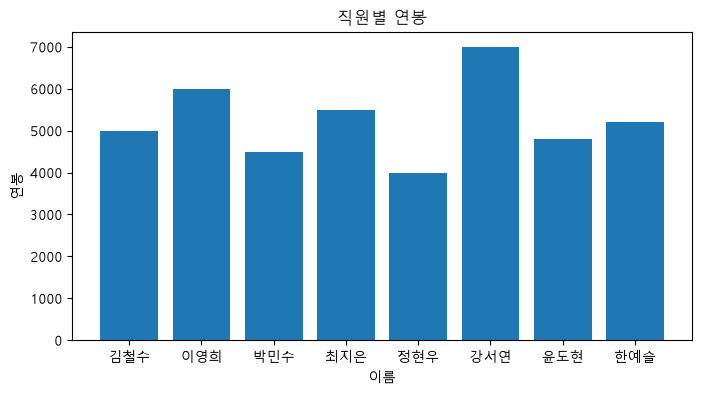

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(emp["name"], emp["salary"])
ax.set_title("직원별 연봉")
ax.set_xlabel("이름")
ax.set_ylabel("연봉")
plt.show()

## 3) 대표 차트 4종 — 언제 무엇을 쓰나

| 차트 | 언제 | 코드 |
|------|------|------|
| **막대 (bar)** | 범주별 값 비교 | `ax.bar(x, y)` |
| **히스토그램 (hist)** | 한 변수의 **분포** | `ax.hist(values, bins=5)` |
| **산점도 (scatter)** | **두 변수의 관계** | `ax.scatter(x, y)` |
| **선 (plot)** | **시간/순서**에 따른 변화 | `ax.plot(x, y)` |

```python
# 히스토그램 — 연봉이 어떻게 퍼져 있나
fig, ax = plt.subplots()
ax.hist(emp["salary"], bins=5)
ax.set_title("연봉 분포")
plt.show()

# 산점도 — 입사연도와 연봉의 관계
fig, ax = plt.subplots()
ax.scatter(emp["hire_year"], emp["salary"])
ax.set_xlabel("입사연도"); ax.set_ylabel("연봉")
plt.show()
```

> 차트 선택이 핵심입니다: **"비교→막대, 분포→히스토그램, 관계→산점도, 추세→선."** 데이터에 안 맞는 차트는 오히려 오해를 부릅니다.

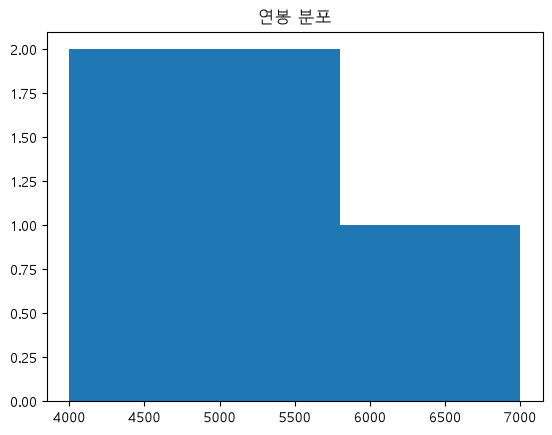

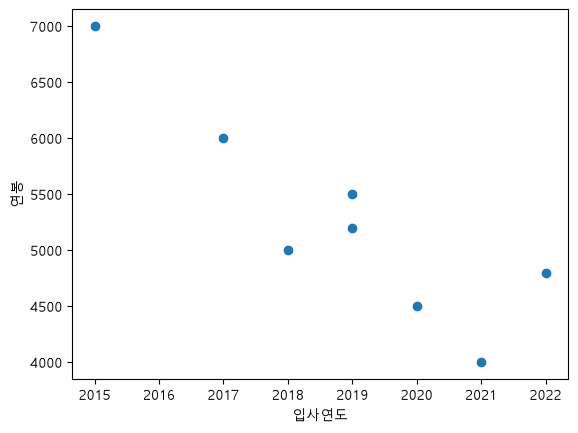

In [5]:
fig, ax = plt.subplots()
ax.hist(emp["salary"], bins=5)
ax.set_title("연봉 분포")
plt.show()

fig, ax = plt.subplots()
ax.scatter(emp["hire_year"], emp["salary"])
ax.set_xlabel("입사연도")
ax.set_ylabel("연봉")
plt.show()

## 4) seaborn — 더 적은 코드로 더 예쁘게

seaborn은 matplotlib 위에 만들어진 라이브러리로, **DataFrame을 바로 받아** 통계 차트를 짧게 그립니다.

```python
# 부서별 평균 연봉 — seaborn은 groupby 없이 알아서 평균 계산
sns.barplot(data=emp.dropna(subset=["dept_id"]), x="dept_id", y="salary")
plt.title("부서별 평균 연봉")
plt.show()
```

> matplotlib로는 직접 `groupby`해서 평균을 구해 `ax.bar`에 넣어야 했지만, seaborn은 **`x`, `y`만 지정하면 집계까지** 해줍니다. (막대 끝의 검은 선은 신뢰구간)

```python
# 박스플롯 — 부서별 연봉 분포(중앙값·사분위·이상치)
sns.boxplot(data=emp, x="dept_id", y="salary")
plt.show()

# 히트맵 — 변수 간 상관관계
sns.heatmap(emp[["salary", "hire_year"]].corr(), annot=True, cmap="coolwarm")
plt.show()
```

> **박스플롯**은 "그룹별 분포"를, **히트맵 + `.corr()`**는 "변수들이 서로 얼마나 관련있나"를 봅니다. 둘 다 EDA의 단골 도구입니다.

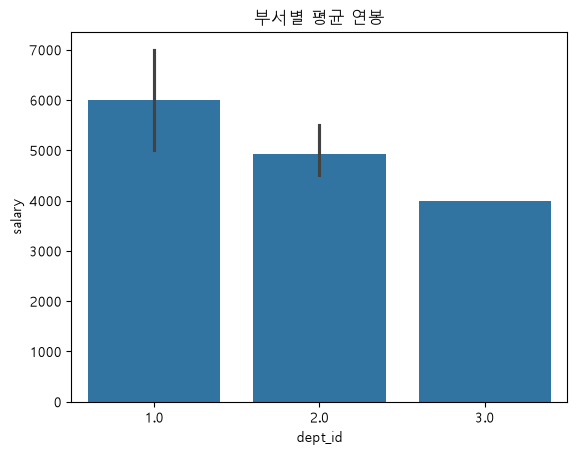

In [6]:
sns.barplot(data=emp.dropna(subset=["dept_id"]), x="dept_id", y="salary")
plt.title("부서별 평균 연봉")
plt.show()

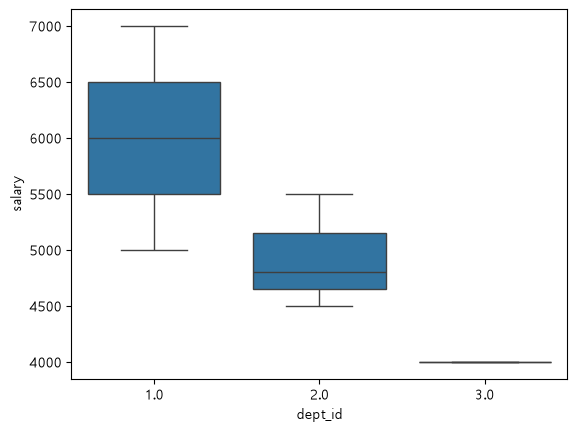

In [7]:
sns.boxplot(data=emp, x="dept_id", y="salary")
plt.show()

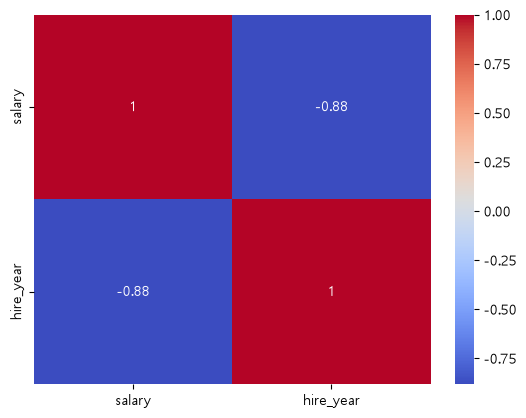

In [8]:
sns.heatmap(emp[["salary", "hire_year"]].corr(), annot=True, cmap="coolwarm")
plt.show()

## 대표 예제 — 입사연도와 연봉의 관계 (산점도 + 상관계수)

> "입사연도와 연봉이 관계있을까?"를 산점도로 보고, 상관계수로 확인하라.

```python
# 상관계수: -1(완전 반대) ~ 0(무관) ~ +1(완전 비례)
corr = emp[["hire_year", "salary"]].corr().iloc[0, 1]
print(f"상관계수: {corr:.4f}")   # 약 -0.88

fig, ax = plt.subplots()
ax.scatter(emp["hire_year"], emp["salary"])
ax.set_title(f"입사연도 vs 연봉 (상관 {corr:.2f})")
ax.set_xlabel("입사연도"); ax.set_ylabel("연봉")
plt.show()
```

**해석:**

```
상관계수: -0.8825
```

> 가르칠 포인트: 상관계수 **-0.88**은 강한 음의 관계 — **최근에 입사할수록(연도↑) 연봉이 낮은**(연봉↓) 경향. 산점도로 보면 점들이 오른쪽 아래로 흐르는 게 보입니다. "그림으로 패턴을 발견 → 숫자(상관계수)로 확인"이 EDA의 전형적 흐름입니다. (단, **상관은 인과가 아님** — 근속이 길어 연봉이 높을 뿐, 입사연도가 연봉을 "결정"하는 건 아님)

상관계수: -0.8825


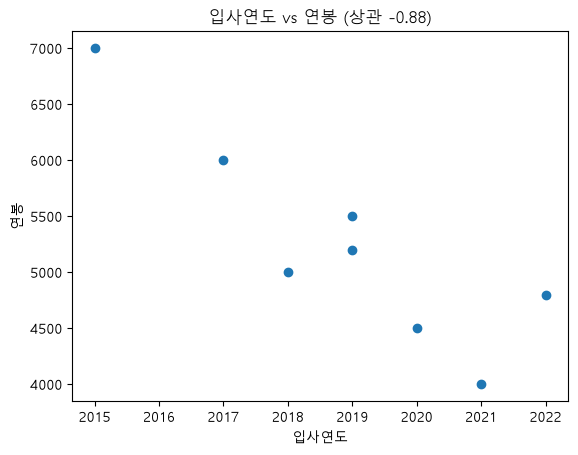

In [9]:
corr = emp[["hire_year", "salary"]].corr().iloc[0, 1]
print(f"상관계수: {corr:.4f}")

fig, ax = plt.subplots()
ax.scatter(emp["hire_year"], emp["salary"])
ax.set_title(f"입사연도 vs 연봉 (상관 {corr:.2f})")
ax.set_xlabel("입사연도")
ax.set_ylabel("연봉")
plt.show()

## 확인 (노트북에서 실행)

시각화는 assert가 어려우니, **에러 없이 그려지는지 + 상관계수 값**으로 확인합니다.

```python
# 차트들이 에러 없이 그려지면 통과
fig, ax = plt.subplots(); ax.bar(emp["name"], emp["salary"]); plt.close(fig)
fig, ax = plt.subplots(); ax.hist(emp["salary"], bins=5); plt.close(fig)
sns.barplot(data=emp.dropna(subset=["dept_id"]), x="dept_id", y="salary"); plt.close()

# 상관계수 값 확인
corr = emp[["hire_year", "salary"]].corr().iloc[0, 1]
assert -0.9 < corr < -0.85    # 약 -0.88
print(f"상관계수 {corr:.4f} — 통과 ✅")
```

In [10]:
fig, ax = plt.subplots(); ax.bar(emp["name"], emp["salary"]); plt.close(fig)
fig, ax = plt.subplots(); ax.hist(emp["salary"], bins=5); plt.close(fig)
sns.barplot(data=emp.dropna(subset=["dept_id"]), x="dept_id", y="salary"); plt.close()

corr = emp[["hire_year", "salary"]].corr().iloc[0, 1]
assert -0.9 < corr < -0.85
print(f"상관계수 {corr:.4f} - 통과 ✅")


상관계수 -0.8825 - 통과 ✅


## 직접 풀어보기 (연습)

차트를 직접 그려 보세요. (눈으로 확인이 주된 목표 — 일부만 값 검증)

### 연습 1 — 부서별 인원 막대그래프

> 부서별(`dept_id`) 인원 수를 막대그래프로 그려라.
> **힌트**: `emp["dept_id"].value_counts()`로 부서별 개수를 구해 `ax.bar(...)`, 또는 `sns.countplot(data=emp, x="dept_id")`.

```python
# TODO: 부서별 인원 막대그래프 그리기
# (정답 차트가 그려지면 OK — 개발3, 영업3, 인사1)
```

### 연습 2 — 연봉 분포 히스토그램

> 전체 직원의 연봉 분포를 히스토그램으로 그려라. (`bins`를 5로)
> **힌트**: `ax.hist(emp["salary"], bins=5)`.

```python
# TODO: 연봉 히스토그램
```

### 연습 3 — 근속연수 파생 후 산점도 (pandas + 시각화)

> `tenure = 2026 - hire_year` 열을 만들고, 근속연수와 연봉의 산점도를 그려라. 그리고 둘의 상관계수를 출력하라.
> **힌트**: 21에서 배운 파생 열 + `ax.scatter` + `.corr()`.

```python
emp2 = emp.copy()
emp2["tenure"] = 2026 - emp2["hire_year"]
# TODO: scatter(tenure, salary) + 상관계수 출력

corr = emp2[["tenure", "salary"]].corr().iloc[0, 1]
assert 0.85 < corr < 0.9      # tenure는 hire_year의 반대 → 양의 상관 (약 +0.88)
print(f"근속-연봉 상관 {corr:.4f} — 통과 ✅")
```